In [21]:
from pathlib import Path
import sys
import json
import math
import tomllib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'src').exists():
    ROOT = Path(r'C:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.cam151_ref_detection.homography_preview import build_homography_preview
from src.cam151_ref_detection.tube_detection_preview import (
    build_tube_detection_preview,
    _pick_detection_roi,
    _warp_detection_roi,
    _estimate_stack_band,
    _normalize_01,
    _smooth_1d,
    _estimate_dominant_period,
    _find_local_peaks_1d,
    _find_best_periodic_peak_run,
    _median_period,
    _fill_missing_seams,
    _extend_periodic_seams,
    _extend_centers_with_support,
    _smooth_x_positions,
    _refine_x_positions_with_canny,
    _enforce_curve_consistency,
    _repair_low_confidence_positions,
    _repair_top_outliers_with_local_sam2,
    _stabilize_x_positions,
)

ARTIFACT_ROOT = ROOT / 'artifacts' / 'notebook_step_by_step'
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
print(ROOT)

c:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean


## 1. Elegir Imagen

La notebook trabaja por defecto con `cam151_wide_20260323_120028.jpg`, que es una de las imagenes sobre las que hemos estado iterando.

Puedes cambiar `IMG_INDEX` o fijar `IMG_NAME` manualmente.

In [22]:
IMG_PATHS = sorted((ROOT / 'test_images').glob('cam151_*.jpg'))
for idx, path in enumerate(IMG_PATHS):
    print(f'[{idx}] {path.name}')

IMG_INDEX = 3
IMG_NAME = IMG_PATHS[IMG_INDEX].name
IMG_PATH = ROOT / 'test_images' / IMG_NAME
TOML_PATH = ROOT / 'manual_rois' / f'{Path(IMG_NAME).stem}_rois.toml'
OUT_DIR = ARTIFACT_ROOT / Path(IMG_NAME).stem
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('IMG_PATH =', IMG_PATH)
print('TOML_PATH =', TOML_PATH)
print('OUT_DIR =', OUT_DIR)

[0] cam151_wide_20260323_100046.jpg
[1] cam151_wide_20260323_102005.jpg
[2] cam151_wide_20260323_103026.jpg
[3] cam151_wide_20260323_120028.jpg
[4] cam151_wide_20260323_140058.jpg
IMG_PATH = c:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\test_images\cam151_wide_20260323_120028.jpg
TOML_PATH = c:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\manual_rois\cam151_wide_20260323_120028_rois.toml
OUT_DIR = c:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\artifacts\notebook_step_by_step\cam151_wide_20260323_120028


In [23]:
def show_bgr(img_or_path, title=None, figsize=(8, 12)):
    if isinstance(img_or_path, (str, Path)):
        img = cv2.imread(str(img_or_path), cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(img_or_path)
    else:
        img = img_or_path
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


def draw_manual_annotations(image_bgr, rois, points, lines):
    vis = image_bgr.copy()

    for roi in rois:
        x1, y1, x2, y2 = [int(round(v)) for v in roi.get('xyxy', [0, 0, 0, 0])]
        note = str(roi.get('note') or roi.get('id') or 'roi')
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(vis, note[:30], (x1 + 6, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2, cv2.LINE_AA)

    for line in lines:
        pts = line.get('points') or line.get('xyxy')
        if pts is None:
            continue
        if isinstance(pts, list) and len(pts) == 4 and isinstance(pts[0], (int, float)):
            x1, y1, x2, y2 = [int(round(v)) for v in pts]
        else:
            (x1, y1), (x2, y2) = pts
            x1, y1, x2, y2 = map(lambda v: int(round(v)), [x1, y1, x2, y2])
        label = str(line.get('label') or line.get('id') or 'line')
        cv2.line(vis, (x1, y1), (x2, y2), (255, 210, 0), 2, cv2.LINE_AA)
        cv2.putText(vis, label[:30], (x1 + 4, max(18, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 210, 0), 1, cv2.LINE_AA)

    for point in points:
        x = int(round(point.get('x', 0)))
        y = int(round(point.get('y', 0)))
        label = str(point.get('label') or point.get('kind') or point.get('id') or 'pt')
        cv2.circle(vis, (x, y), 5, (255, 0, 255), -1, cv2.LINE_AA)
        cv2.putText(vis, label[:30], (x + 6, max(18, y - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 255), 1, cv2.LINE_AA)

    return vis

## 2. Cargar Imagen Y Anotaciones Manuales

Aqui cargamos la imagen original y el TOML exportado desde la app web.

Las anotaciones manuales son la base de dos cosas:
- la homografia,
- la ROI inferior que se usa para sembrar la deteccion de tubos.

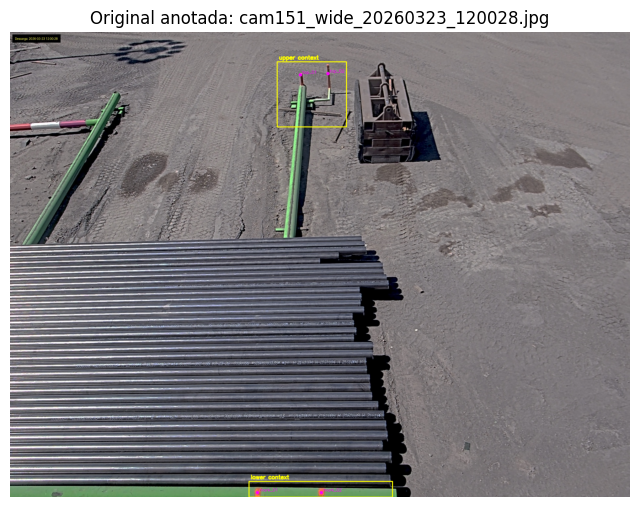

ROIs: 2 | points: 4 | lines: 3


In [24]:
image_bgr = cv2.imread(str(IMG_PATH), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise FileNotFoundError(IMG_PATH)

with open(TOML_PATH, 'rb') as f:
    data = tomllib.load(f)

rois = data.get('rois', [])
points = data.get('points', [])
lines = data.get('lines', [])

annotated = draw_manual_annotations(image_bgr, rois, points, lines)
show_bgr(annotated, f'Original anotada: {IMG_NAME}', figsize=(8, 12))
print('ROIs:', len(rois), '| points:', len(points), '| lines:', len(lines))

## 3. Construir La Homografia

La homografia sale de las referencias anotadas en la app.

Actualmente, el constructor puede trabajar de dos formas:
- con guias paralelas (`top_01 -> mark_01`, `top_02 -> mark_02`, `top_ref`, `bottom_horrizontal`),
- o solo con lineas horizontales si no hay suficientes guias.

En nuestro caso estamos usando la primera opcion.

In [25]:
homography = build_homography_preview(
    image_path=IMG_PATH,
    lines=lines,
    points=points,
    output_dir=OUT_DIR / '01_homography',
)

print('src_points =', homography.src_points)
print('output_size =', homography.output_size)
print('overlay =', homography.overlay_path)
print('warp =', homography.warp_path)

src_points = [(950.88671875, 219.84735107421875), (1258.8997802734375, 194.20828247070312), (816.4243774414062, 1526.593994140625), (1304.1180419921875, 1532.947021484375)]
output_size = (478, 1323)
overlay = c:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\artifacts\notebook_step_by_step\cam151_wide_20260323_120028\01_homography\homography_overlay.jpg
warp = c:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\artifacts\notebook_step_by_step\cam151_wide_20260323_120028\01_homography\homography_warp.jpg


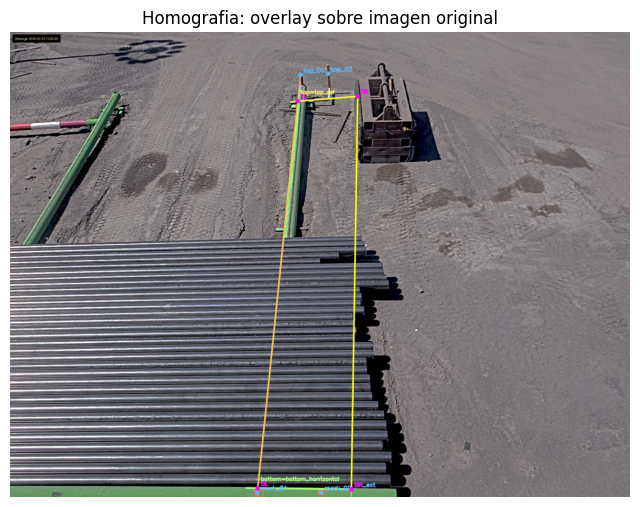

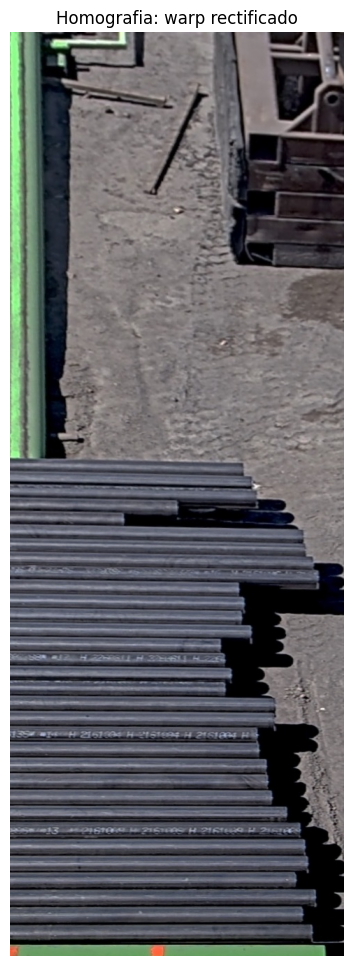

In [26]:
show_bgr(homography.overlay_path, 'Homografia: overlay sobre imagen original', figsize=(8, 12))
show_bgr(homography.warp_path, 'Homografia: warp rectificado', figsize=(8, 12))

## 4. Elegir Y Proyectar La `tube ROI`

No detectamos tubos sobre todo el `warp`. Primero elegimos una ROI inferior anotada manualmente y la proyectamos al `warp`.

Luego la expandimos:
- hacia arriba, para incluir el paquete completo,
- hasta la derecha del `warp`, para no cortar las puntas.

In [27]:
warp_bgr = cv2.imread(str(homography.warp_path), cv2.IMREAD_COLOR)
selected_roi = _pick_detection_roi(rois)
detection_roi = _warp_detection_roi(
    selected_roi,
    homography.src_points,
    homography.output_size,
    warp_bgr.shape,
)
print('selected_roi =', selected_roi)
print('initial detection_roi =', detection_roi)

if detection_roi is not None:
    stack_band = _estimate_stack_band(warp_bgr, detection_roi[0], detection_roi[2])
    print('stack_band =', stack_band)
    if stack_band is not None:
        band_y0, band_y1, run, period = stack_band
        top_expand = max(220, int(round(13.0 * float(period or 22.0))))
        detection_roi = (
            int(detection_roi[0]),
            int(min(detection_roi[1], max(0, band_y0 - top_expand))),
            int(detection_roi[2]),
            int(max(detection_roi[3], band_y1)),
        )

print('expanded detection_roi =', detection_roi)

selected_roi = {'id': 'roi_02', 'note': 'lower context', 'xyxy': [789, 1484, 1263, 1536]}
initial detection_roi = (0, 921, 478, 1323)
stack_band = (628, 1318, [649, 672, 703, 726, 745, 765, 786, 804, 823, 844, 867, 884, 905, 926, 947, 969, 994, 1013, 1035, 1058, 1080, 1104, 1127, 1150, 1175, 1199, 1223, 1248, 1274, 1302], 23.0)
expanded detection_roi = (0, 329, 478, 1323)


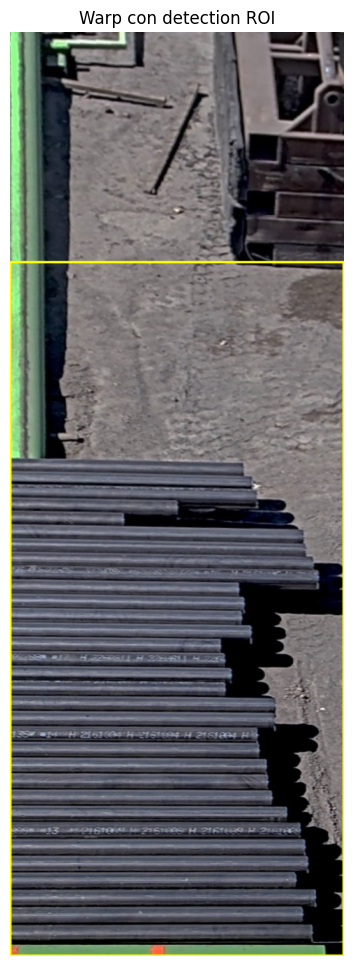

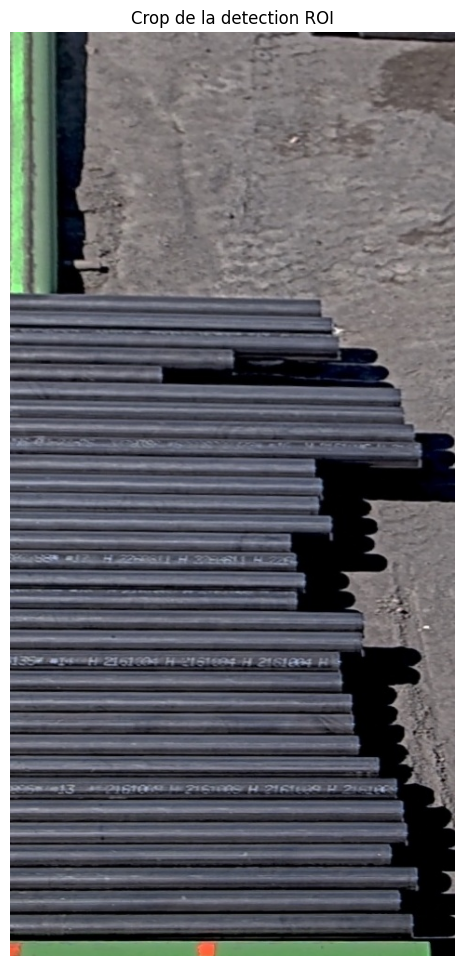

In [28]:
warp_vis = warp_bgr.copy()
if detection_roi is not None:
    x0, y0, x1, y1 = detection_roi
    cv2.rectangle(warp_vis, (x0, y0), (x1 - 1, y1 - 1), (0, 255, 255), 2, cv2.LINE_AA)
show_bgr(warp_vis, 'Warp con detection ROI', figsize=(8, 12))

x0, y0, x1, y1 = detection_roi
warp_crop = warp_bgr[y0:y1, x0:x1].copy()
show_bgr(warp_crop, 'Crop de la detection ROI', figsize=(8, 12))

## 5. Perfil Vertical Para Detectar Filas De Tubos

Aqui empieza la deteccion automatica sobre la ROI del `warp`.

La idea es:
- tomar una franja central de la ROI,
- suavizar horizontalmente,
- construir un perfil de oscuridad por fila,
- estimar el periodo vertical dominante,
- detectar costuras (`seams`) entre tubos.

In [29]:
gray = cv2.cvtColor(warp_crop, cv2.COLOR_BGR2GRAY)
h, w = gray.shape[:2]

strip_x0 = 0
strip_x1 = min(w - 8, max(54, int(round(0.14 * float(w)))))
if strip_x1 <= strip_x0 + 20:
    strip_x0 = 0
    strip_x1 = min(w, max(32, int(round(0.18 * float(w)))))

gray_strip = gray[:, strip_x0:strip_x1]
blur_x = cv2.GaussianBlur(gray_strip, (71, 1), 0)
dark_profile = 255.0 - np.mean(blur_x.astype(np.float32), axis=1)
profile_smooth = _smooth_1d(dark_profile, 9)
profile_norm = _normalize_01(profile_smooth)

strong_rows = np.flatnonzero(profile_norm >= max(0.30, float(np.percentile(profile_norm, 70))))
energy_start_index = int(strong_rows[0]) if strong_rows.size else 0
profile_cut = profile_norm[energy_start_index:]
dominant_period, _autocorr = _estimate_dominant_period(profile_cut, min_period_frac=0.03, max_period_frac=0.18)

min_distance = 16
if dominant_period is not None and np.isfinite(dominant_period):
    min_distance = max(12, int(round(0.65 * float(dominant_period))))
base_threshold = max(0.32, float(np.percentile(profile_norm, 72)))
peaks_index = _find_local_peaks_1d(profile_norm, threshold=base_threshold, min_distance=min_distance)
peaks_index = [int(p) for p in peaks_index if p >= energy_start_index]

print('strip_x0, strip_x1 =', strip_x0, strip_x1)
print('energy_start_index =', energy_start_index)
print('dominant_period =', dominant_period)
print('raw peaks =', peaks_index[:20], '... total =', len(peaks_index))

strip_x0, strip_x1 = 0 67
energy_start_index = 296
dominant_period = 22.0
raw peaks = [299, 318, 337, 356, 373, 393, 411, 433, 454, 472, 491, 513, 535, 553, 575, 596, 617, 639, 661, 683] ... total = 32


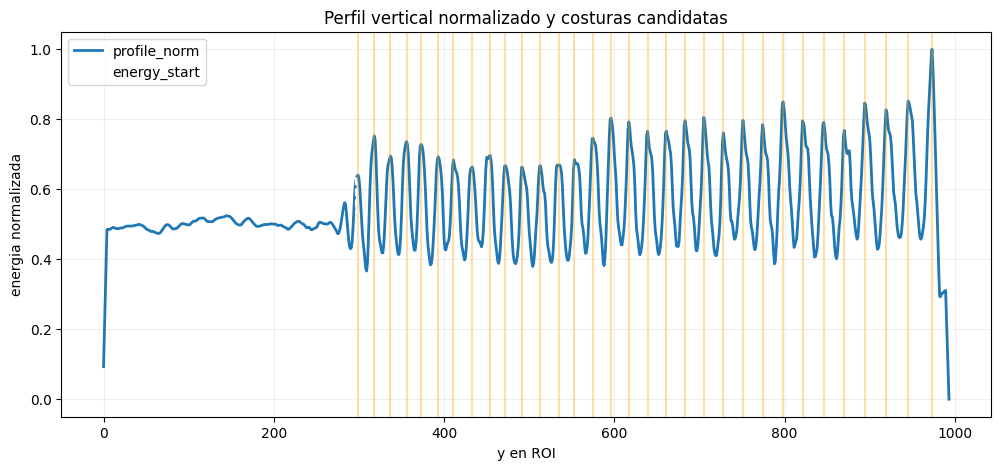

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
y = np.arange(profile_norm.size)
ax.plot(y, profile_norm, label='profile_norm', lw=2)
ax.axvline(energy_start_index, color='white', linestyle='--', label='energy_start')
for p in peaks_index:
    ax.axvline(p, color='orange', alpha=0.35)
ax.set_title('Perfil vertical normalizado y costuras candidatas')
ax.set_xlabel('y en ROI')
ax.set_ylabel('energia normalizada')
ax.grid(True, alpha=0.2)
ax.legend()
plt.show()

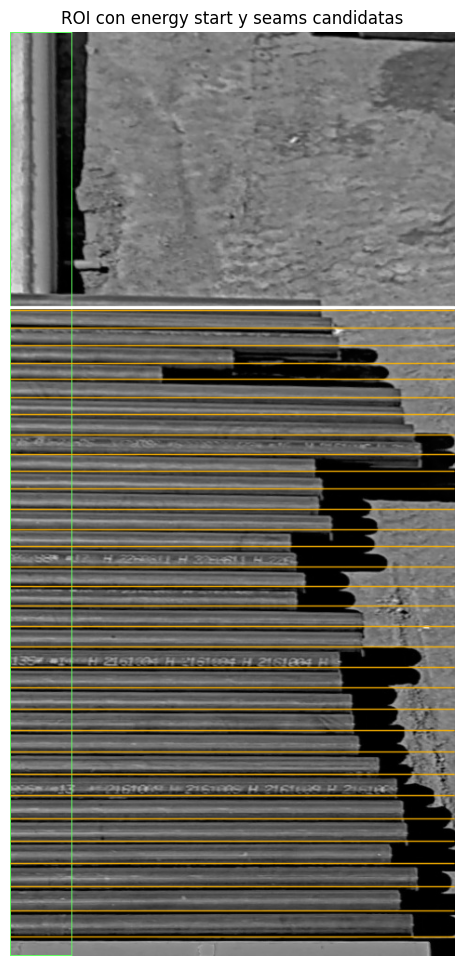

In [31]:
profile_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.rectangle(profile_vis, (strip_x0, 0), (strip_x1 - 1, h - 1), (96, 255, 96), 1)
cv2.line(profile_vis, (0, energy_start_index), (w - 1, energy_start_index), (255, 255, 255), 2, cv2.LINE_AA)
for p in peaks_index:
    cv2.line(profile_vis, (0, p), (w - 1, p), (0, 180, 255), 1, cv2.LINE_AA)
show_bgr(profile_vis, 'ROI con energy start y seams candidatas', figsize=(8, 12))

## 6. Completar Costuras Y Construir Centros De Tubo

Las costuras candidatas se filtran por periodicidad y se rellenan cuando falta una intermedia.

Con esas costuras ya se generan centros `Y` para cada tubo.

In [32]:
run_peaks, run_period = _find_best_periodic_peak_run(peaks_index, gap_lo=14, gap_hi=34, min_len=6)
median_period = _median_period(run_peaks or peaks_index)
period_used = run_period or median_period or dominant_period or 22.0

peaks_filled = _fill_missing_seams(run_peaks or peaks_index, period_used)
peaks_filled = _extend_periodic_seams(
    peaks_filled,
    peaks_index,
    period_used,
    profile_norm,
    y_min=max(0, energy_start_index - int(round(0.6 * float(period_used)))),
    y_max=int(profile_norm.size - 1),
)

lo_gap = max(12.0, 0.55 * float(period_used))
hi_gap = max(lo_gap + 1.0, 1.55 * float(period_used))
centers_list = []
edge_top_list = []
edge_bot_list = []
for prev, curr in zip(peaks_filled[:-1], peaks_filled[1:]):
    gap = float(curr - prev)
    if lo_gap <= gap <= hi_gap:
        edge_top_list.append(int(prev))
        edge_bot_list.append(int(curr))
        centers_list.append(int(round(0.5 * (float(prev) + float(curr)))))

centers = np.asarray(
    _extend_centers_with_support(
        centers_list,
        period_used,
        gray,
        strip_x0,
        strip_x1,
    ),
    np.int32,
)

print('period_used =', period_used)
print('run_peaks[:10] =', run_peaks[:10])
print('peaks_filled[:20] =', peaks_filled[:20])
print('tube centers[:20] =', centers[:20].tolist())
print('tube count from centers =', len(centers))

period_used = 22.0
run_peaks[:10] = [299, 318, 337, 356, 373, 393, 411, 433, 454, 472]
peaks_filled[:20] = [299, 318, 337, 356, 373, 393, 411, 433, 454, 472, 491, 513, 535, 553, 575, 596, 617, 639, 661, 683]
tube centers[:20] = [220, 242, 264, 286, 308, 328, 346, 364, 383, 402, 422, 444, 463, 482, 502, 524, 544, 564, 586, 606]
tube count from centers = 36


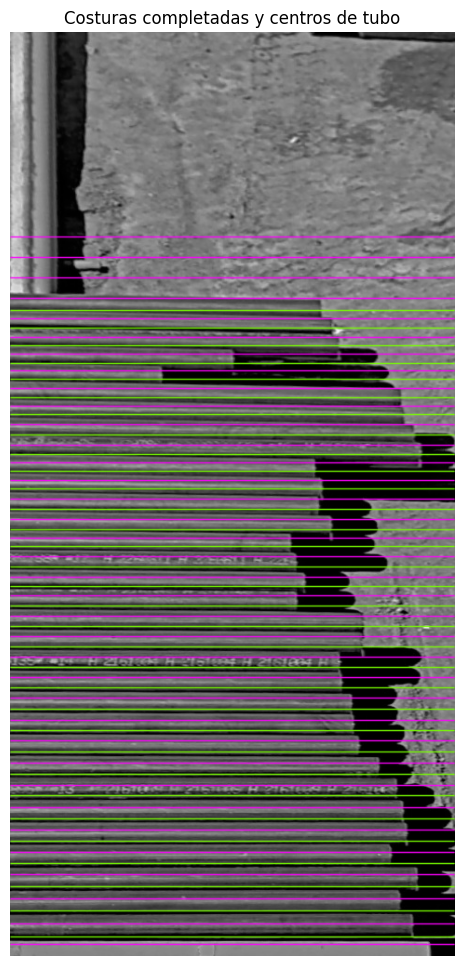

In [33]:
centers_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for p in peaks_filled:
    cv2.line(centers_vis, (0, int(p)), (w - 1, int(p)), (0, 255, 120), 1, cv2.LINE_AA)
for c in centers:
    cv2.line(centers_vis, (0, int(c)), (w - 1, int(c)), (255, 0, 255), 1, cv2.LINE_AA)
show_bgr(centers_vis, 'Costuras completadas y centros de tubo', figsize=(8, 12))

## 7. Estimacion Inicial Del Extremo Derecho (`x_start`) Con Sobel X

Antes del refinamiento fino, el pipeline hace una estimacion gruesa:
- blur vertical fuerte,
- Sobel X con signo,
- elegir el borde mas fuerte en una banda de busqueda a la derecha.

Aqui todavia hay muchos errores por sombra. Por eso despues viene el refinamiento local.

In [34]:
pre_blur = cv2.GaussianBlur(gray, (1, 61), 0)
grad_x = cv2.Sobel(pre_blur.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
grad_x_pos = np.maximum(grad_x, 0.0)
grad_x_neg = np.maximum(-grad_x, 0.0)

x_search0 = max(int(round(0.48 * float(w))), strip_x0)
x_search1 = max(x_search0 + 8, min(w, int(round(0.98 * float(w)))))

raw_x_positions = []
for y_center in centers:
    y0 = max(0, int(y_center) - 4)
    y1 = min(gray.shape[0] - 1, int(y_center) + 4)
    strip_pos = grad_x_pos[y0:y1 + 1, x_search0:x_search1]
    strip_neg = grad_x_neg[y0:y1 + 1, x_search0:x_search1]
    if strip_pos.size == 0 or strip_neg.size == 0:
        continue
    prof_pos_raw = np.percentile(strip_pos, 90, axis=0).astype(np.float32)
    prof_neg_raw = np.percentile(strip_neg, 90, axis=0).astype(np.float32)
    if prof_pos_raw.size == 0 or prof_neg_raw.size == 0:
        continue
    prof_pos = np.power(_normalize_01(prof_pos_raw), 6.0)
    prof_neg = np.power(_normalize_01(prof_neg_raw), 6.0)
    neg_max = float(np.max(prof_neg)) if prof_neg.size else 0.0
    pos_max = float(np.max(prof_pos)) if prof_pos.size else 0.0
    if max(neg_max, pos_max) <= 1e-6:
        continue
    neg_idx = int(np.argmax(prof_neg))
    pos_idx = int(np.argmax(prof_pos))
    if neg_max >= max(0.18, 0.55 * pos_max):
        x_sel = int(x_search0 + neg_idx)
    else:
        x_sel = int(x_search0 + pos_idx)
    raw_x_positions.append(float(x_sel))

raw_x_positions = _smooth_x_positions(raw_x_positions)
print('raw_x_positions[:12] =', [round(v, 1) for v in raw_x_positions[:12]])

raw_x_positions[:12] = [249.0, 249.0, 298.0, 330.0, 343.0, 343.0, 240.0, 240.0, 416.0, 416.0, 436.0, 436.0]


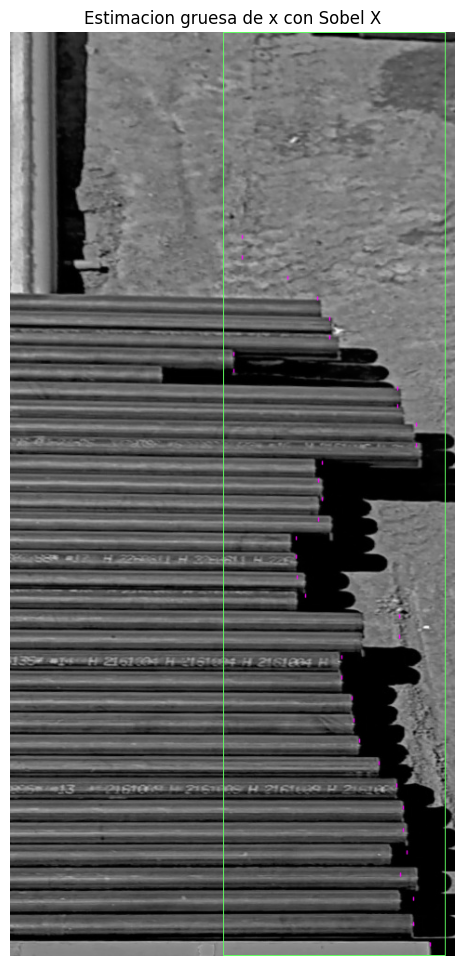

In [ ]:
raw_vis = cv2.cvtColor(gray, cvActualia el archi2.COLOR_GRAY2BGR)
cv2.rectangle(raw_vis, (x_search0, 0), (x_search1 - 1, h - 1), (96, 255, 96), 1)
for y_center, x_val in zip(centers, raw_x_positions):
    cv2.line(raw_vis, (int(round(x_val)), int(y_center) - 2), (int(round(x_val)), int(y_center) + 2), (255, 0, 255), 1, cv2.LINE_AA)
show_bgr(raw_vis, 'Estimacion gruesa de x con Sobel X', figsize=(8, 12))

## 8. Refinamiento Local Del Extremo

El refinamiento actual hace varias etapas:
1. `_refine_x_positions_with_canny(...)`
2. `_enforce_curve_consistency(...)`
3. `_repair_low_confidence_positions(...)`
4. `_repair_top_outliers_with_local_sam2(...)`
5. `_stabilize_x_positions(...)`

Aqui mostramos cada lista para que se vea como se va corrigiendo la curva.

In [41]:
local_x_positions, local_confidences = _refine_x_positions_with_canny(
    gray,
    centers,
    raw_x_positions,
    x_search0,
    x_search1,
    warp_crop,
)
curve_x_positions = _enforce_curve_consistency(centers, local_x_positions)
repair_x_positions = _repair_low_confidence_positions(centers, curve_x_positions, local_confidences)
outlier_fix_x_positions = _repair_top_outliers_with_local_sam2(warp_crop, centers, repair_x_positions)
final_x_positions = _stabilize_x_positions(centers, outlier_fix_x_positions)

print('local_x_positions[:12]      =', [round(v, 1) for v in local_x_positions[:12]])
print('curve_x_positions[:12]      =', [round(v, 1) for v in curve_x_positions[:12]])
print('repair_x_positions[:12]     =', [round(v, 1) for v in repair_x_positions[:12]])
print('outlier_fix_x_positions[:12]=', [round(v, 1) for v in outlier_fix_x_positions[:12]])
print('final_x_positions[:12]      =', [round(v, 1) for v in final_x_positions[:12]])
print('local_confidences[:12]      =', [round(v, 2) for v in local_confidences[:12]])

local_x_positions[:12]      = [249.0, 249.0, 298.0, 330.0, 334.0, 330.0, 240.0, 240.0, 416.0, 420.0, 436.0, 436.0]
curve_x_positions[:12]      = [278.0, 281.0, 298.0, 306.8, 311.0, 311.0, 302.8, 302.8, 337.4, 341.1, 347.1, 347.1]
repair_x_positions[:12]     = [276.1, 282.4, 288.8, 295.2, 300.3, 300.5, 304.5, 306.8, 322.0, 326.7, 329.4, 329.4]
outlier_fix_x_positions[:12]= [276.1, 282.4, 288.8, 295.2, 300.3, 300.5, 304.5, 306.8, 326.7, 331.4, 331.4, 334.5]
final_x_positions[:12]      = [276.1, 282.4, 288.8, 295.2, 300.3, 300.5, 304.5, 306.8, 326.7, 331.4, 331.4, 334.5]
local_confidences[:12]      = [0.12, 0.12, 0.12, 0.16, 0.43, 0.12, 0.12, 0.12, 0.33, 0.61, 0.12, 0.12]


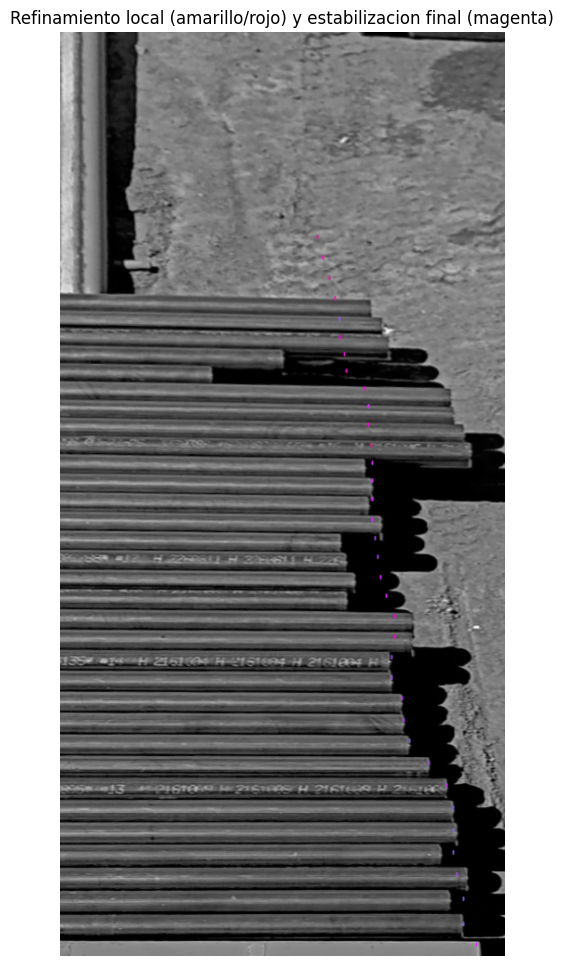

: 

In [ ]:
refine_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for y_center, x_local, x_final, conf_val in zip(centers, outlier_fix_x_positions, final_x_positions, local_confidences):
    y0 = max(0, int(y_center) - 2)
    y1 = min(refine_vis.shape[0] - 1, int(y_center) + 2)
    color = (0, 0, 255) if float(conf_val) < 0.35 else (255, 255, 0)
    cv2.line(refine_vis, (int(round(x_local)), y0), (int(round(x_local)), y1), color, 1, cv2.LINE_AA)
    cv2.line(refine_vis, (int(round(x_final)), y0), (int(round(x_final)), y1), (255, 0, 255), 1, cv2.LINE_AA)
show_bgr(refine_vis, 'Refinamiento local (amarillo/rojo) y estabilizacion final (magenta)', figsize=(8, 12))

## 9. Resultado Final Del Pipeline

Esta celda ejecuta la funcion de alto nivel `build_tube_detection_preview(...)` y permite comparar el resultado final contra el recorrido manual paso a paso.

In [38]:
result = build_tube_detection_preview(
    image_path=IMG_PATH,
    lines=lines,
    points=points,
    rois=rois,
    output_dir=OUT_DIR / '02_final_preview',
)

print('tube_count =', result.tube_count)
print('dominant_period =', result.dominant_period)
print('energy_start_index =', result.energy_start_index)
print('detection_roi =', result.detection_roi)
print('overlay =', result.detection_overlay_path)

tube_count = 36
dominant_period = 22.0
energy_start_index = 625
detection_roi = (0, 329, 478, 1323)
overlay = c:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\artifacts\notebook_step_by_step\cam151_wide_20260323_120028\02_final_preview\tube_detection_warp.jpg


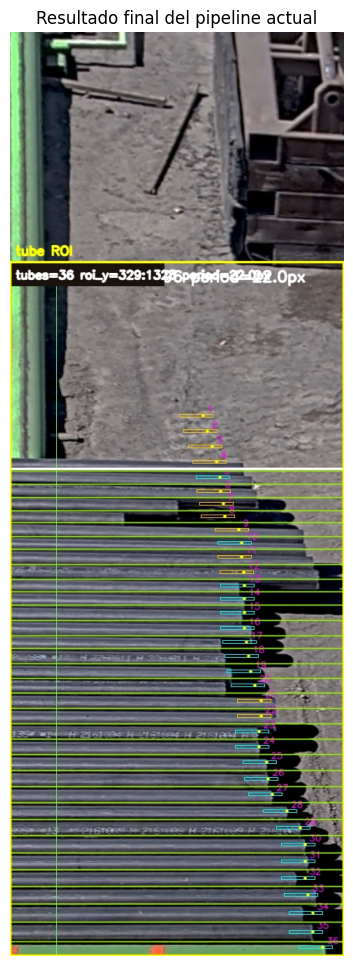

In [39]:
show_bgr(result.detection_overlay_path, 'Resultado final del pipeline actual', figsize=(8, 12))

## 10. Ventanas Locales De Los Primeros Tubos

Estas ventanas son utiles para diagnosticar por que fallan los tubos altos.

En la practica, la mayor parte de los errores residuales se concentran aqui:
- tubos parciales de arriba,
- sombra muy marcada a la derecha,
- poco contexto del cuerpo del tubo.

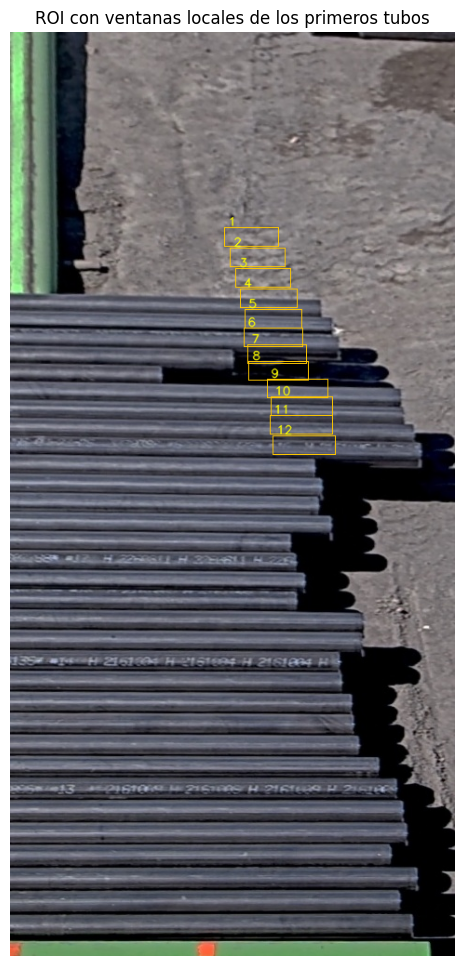

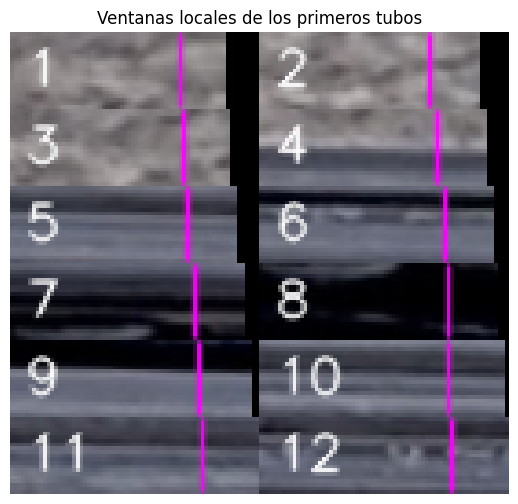

In [40]:
def make_local_window_sheet(roi_bgr, centers, x_vals, tube_count, x_search0, x_search1, rows=12):
    from src.cam151_ref_detection.tube_detection_preview import _local_search_bounds

    panels = []
    overlay = roi_bgr.copy()
    total = len(x_vals)
    for idx in range(min(rows, total)):
        yc = int(round(float(centers[idx])))
        x_local = float(x_vals[idx])
        lo, hi = _local_search_bounds(x_local, x_search0, x_search1, idx, tube_count)
        py0 = max(0, yc - 10)
        py1 = min(roi_bgr.shape[0] - 1, yc + 10)
        px0 = max(0, lo - 10)
        px1 = min(roi_bgr.shape[1] - 1, hi + 8)
        patch = roi_bgr[py0:py1 + 1, px0:px1 + 1].copy()
        if patch.size == 0:
            continue
        xl = int(round(x_local - px0))
        cv2.line(patch, (max(0, min(patch.shape[1] - 1, xl)), 0), (max(0, min(patch.shape[1] - 1, xl)), patch.shape[0] - 1), (255, 0, 255), 1, cv2.LINE_AA)
        cv2.putText(patch, str(idx + 1), (4, 14), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)
        panels.append(patch)
        cv2.rectangle(overlay, (px0, py0), (px1, py1), (0, 200, 255), 1)
        cv2.putText(overlay, str(idx + 1), (px0 + 4, max(14, py0 - 2)), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (0, 255, 255), 1, cv2.LINE_AA)

    max_w = max(p.shape[1] for p in panels)
    max_h = max(p.shape[0] for p in panels)
    padded = []
    for p in panels:
        canvas = np.zeros((max_h, max_w, 3), np.uint8)
        canvas[:p.shape[0], :p.shape[1]] = p
        padded.append(canvas)

    rows_out = []
    for i in range(0, len(padded), 2):
        chunk = padded[i:i+2]
        if len(chunk) == 1:
            chunk.append(np.zeros_like(padded[0]))
        rows_out.append(np.hstack(chunk))
    sheet = np.vstack(rows_out)
    return overlay, sheet

local_overlay, local_sheet = make_local_window_sheet(
    warp_crop,
    centers,
    outlier_fix_x_positions,
    tube_count=len(outlier_fix_x_positions),
    x_search0=x_search0,
    x_search1=x_search1,
)
show_bgr(local_overlay, 'ROI con ventanas locales de los primeros tubos', figsize=(8, 12))
show_bgr(local_sheet, 'Ventanas locales de los primeros tubos', figsize=(8, 6))

## 11. Observaciones Actuales

Resumen honesto del estado del pipeline hoy:

- La homografia ya es suficientemente estable para trabajar sobre el paquete derecho.
- El detector de filas en `Y` es bastante mejor que el detector de puntas en `X`.
- Los errores mas duros siguen concentrados en los tubos altos parciales.
- `x_end_estimate` hoy se reporta igual que `x_local`; todavia no hay un estimador independiente completamente robusto del extremo.
- El siguiente paso razonable es mejorar solo esos tubos ambiguos, no reescribir todo el pipeline.